Here: out-of-sample & walk-forward testing 

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import coint
from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm

prices = pd.read_csv(
    "../data/processed/clean_prices.csv",
    index_col=0,
    parse_dates=True
)

prices = prices.dropna()

prices.head()

,KO,PEP
Date,,
2018-01-02,34.816475,89.690910
2018-01-03,34.740017,89.455414
2018-01-04,35.229328,89.896042
2018-01-05,35.221661,90.154335
2018-01-08,35.168156,89.637733


In [30]:
print("Start:", prices.index.min())
print("End:", prices.index.max())
print("Rows:", len(prices))

Start: 2018-01-02 00:00:00
End: 2026-10-06 00:00:00
Rows: 2202


1. Split the data
*70:30 train-test split (as usual)

In [31]:
split_idx = int(len(prices) * 0.7)

train = prices.iloc[:split_idx].copy()
test = prices.iloc[split_idx:].copy()

print("Train:", train.index.min(), "→", train.index.max())
print("Test :", test.index.min(), "→", test.index.max())

Train: 2018-01-02 00:00:00 → 2024-02-15 00:00:00
Test : 2024-02-16 00:00:00 → 2026-10-06 00:00:00


2. Estimate the hedge ratio ONLY on training data

In [32]:
x = train["PEP"]
y = train["KO"]

X = sm.add_constant(x)

model = OLS(y, X).fit()

alpha = model.params["const"]
beta = model.params["PEP"]

print("Alpha:", alpha)
print("Beta :", beta)

Alpha: 11.592675045827967
Beta : 0.27734867355939014


In [33]:
# Spread 

train["spread"] = train["KO"] - beta * train["PEP"]
test["spread"] = test["KO"] - beta * test["PEP"]

train[["KO", "PEP", "spread"]].head()

,KO,PEP,spread
Date,,,
2018-01-02,34.816475,89.690910,9.940820
2018-01-03,34.740017,89.455414,9.929677
2018-01-04,35.229328,89.896042,10.296780
2018-01-05,35.221661,90.154335,10.217475
2018-01-08,35.168156,89.637733,10.307249


In [34]:
# Trouble shooting : define the instance 'window' 
window = 60

combined = pd.concat([
    train[["spread"]],
    test[["spread"]]
])

rolling_mean = combined["spread"].rolling(window).mean()
rolling_std = combined["spread"].rolling(window).std()

combined["z_score"] = (
    combined["spread"] - rolling_mean
) / rolling_std

test["z_score"] = combined.loc[test.index, "z_score"]

test[["spread", "z_score"]].head()

,spread,z_score
Date,,
2024-02-16,13.201694,0.942151
2024-02-20,13.828588,1.771346
2024-02-21,14.282732,2.291612
2024-02-22,14.344985,2.252515
2024-02-23,14.052650,1.780751


4. Generate out-of-sample positions 

In [35]:
def generate_positions(z, entry=2.0, exit=0.5):
    position = pd.Series(0, index=z.index)

    current = 0

    for i in range(len(z)):
        value = z.iloc[i]

        if current == 0:
            if value > entry:
                current = -1
            elif value < -entry:
                current = 1

        elif current == 1:
            if value >= -exit:
                current = 0

        elif current == -1:
            if value <= exit:
                current = 0

        position.iloc[i] = current

    return position

In [36]:
test["position"] = generate_positions(
    test["z_score"],
    entry=2.0,
    exit=0.5
)

test["position"].value_counts()

position
-1    389
 0    175
 1     97
Name: count, dtype: int64

5. Calculate OOS return

In [37]:
# Daily percentage returns of each stock
test["KO_ret"] = test["KO"].pct_change()
test["PEP_ret"] = test["PEP"].pct_change()

# Pairs trading return
# position = +1: long KO / short PEP
# position = -1: short KO / long PEP

test["strategy_ret"] = (
    test["position"].shift(1) *
    (test["KO_ret"] - beta * test["PEP_ret"])
)

test["strategy_ret"] = test["strategy_ret"].fillna(0)

# Equity curve
test["equity"] = (
    1 + test["strategy_ret"]
).cumprod()

6. Calculate performance 

In [38]:
total_return = test["equity"].iloc[-1] - 1

annualized_return = (
    (1 + total_return) ** (252 / len(test)) - 1
)

annualized_vol = (
    test["strategy_ret"].std() * np.sqrt(252)
)

sharpe = (
    annualized_return / annualized_vol
    if annualized_vol != 0
    else np.nan
)

print(f"Total Return: {total_return:.2%}")
print(f"Annualized Return: {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_vol:.2%}")
print(f"Sharpe Ratio: {sharpe:.2f}")

Total Return: -32.90%
Annualized Return: -14.11%
Annualized Volatility: 12.54%
Sharpe Ratio: -1.13


7. Plot the OOS sample 

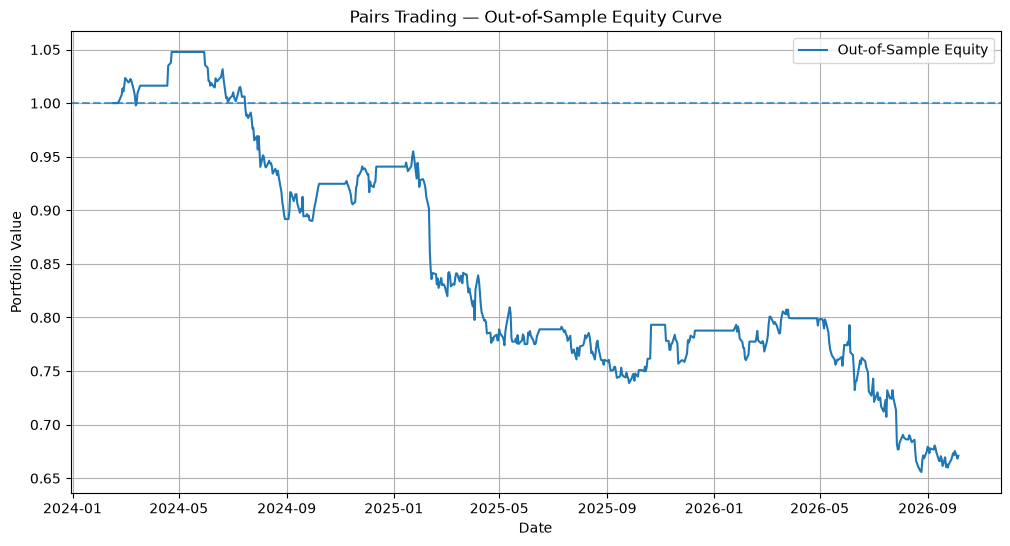

In [39]:
plt.figure(figsize=(12, 6))

plt.plot(
    test.index,
    test["equity"],
    label="Out-of-Sample Equity"
)

plt.axhline(
    1,
    linestyle="--",
    alpha=0.7
)

plt.title("Pairs Trading — Out-of-Sample Equity Curve")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend()
plt.grid(True)
plt.show()

8. Save the results 

In [40]:
test.to_csv(
    "../data/processed/out_of_sample_results.csv"
)

print("Saved:")
print("../data/processed/out_of_sample_results.csv")

Saved:
../data/processed/out_of_sample_results.csv
